In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# LLM 선언 - AzureOpenAI 로 활용해도 됨

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini") 
small_llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
from langchain_core.tools import tool


@tool
def add(a: int, b:int) -> int:
    """
        숫자 a 와 b를 더합니다    
    """
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """
        숫자 a 와 b를 곱합니다    
    """
    return a * b


In [4]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()


In [5]:
# Gmail 도구를 추가
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)
from langchain_google_community import GmailToolkit

# 이 방식을 추천 => 변수를 넘기면서 credential, token json 파일을 관리할 수 있다
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",   # credentials를 기반으로 메일 권한을 가지고 토큰을 생성해서 파일에 저장
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",   #client_sercret_file 오타가 있는 파라미터로...
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)

# 한번 인증을 받으면, 다시 실행해도 넘어간다. 
# gmail_toolkit에서 도구를 받아올 수 있는 상태. 
gmail_tool_list = gmail_toolkit.get_tools()
# toolkit = GmailToolkit()   # 이걸 활용하고자 한다면 -> 파일 이름 명시 불가. credential.json이라고만 해줘야 함 (위 코드 참고)

C:\Users\KE126\AppData\Local\Temp\ipykernel_3452\1902096436.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\KE126\AppData\Local\Temp\ipykernel_3452\1902096436.py:14: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [6]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x0000021C85091BE0>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x0000021C85091BE0>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x0000021C85091BE0>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x0000021C85091BE0>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x0000021C85091BE0>)]

#### langgraph에서 ToolNode

In [8]:
from langgraph.prebuilt import ToolNode

# tool_list = [add, multiply, search_tool, gmail_tool_list]
tool_list = [add, multiply, search_tool] + gmail_tool_list  

llm_with_tools = small_llm.bind_tools(tool_list)  # LLM 바인딩 
tool_node = ToolNode(tool_list)   # 랭그래프 바인딩 

In [7]:
# state 선언 : messages의 경우, langgraph가 내장으로 제공하는 state가 있다
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)



In [8]:
# 1. 에이전트 노드를 생성 <- LLM을 호출하는, llm_with_tools는 messages를 넣어서 invoke만 하는 용도로...

# HumanMessage -> messages 에 추가
# AiMessage -> messages 에 추가
# ToolMessage -> messages 에 추가
# 추가할 때, append 할 필요는 아니고, add_messages 함수를 활용해서 추가할 수 있다.

def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)   # ai_messages와 동일
    
    return {'messages':[response]}

In [9]:
# toolNode <=======>  agent  =====답변완료 ===> END
# agent는 조건이 있는 것. -> conditional node로 만들어야 함 (정보가 다 나왔는지, 아니면 추가적으로 tool을 더 불러와야 하는지)

from langgraph.graph import END
def should_continue(state: MessagesState):
    # agnet노드가 도구를 호출해야 하면, AIMessages에 tool_calls이 포함되어 있다.
    # 답변이 만들어져있으면, tool_calls이 없을거고, content에만 답변이 들어가 있을 것
    messages = state['messages']
    last_ai_message = messages[-1]

    if last_ai_message.tool_calls:
        return 'tools'
    
    return END

In [10]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
# should_continue -> 분간하는 노드는 추가 안함

In [11]:
# 엣지 추가
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', END]
)

graph_builder.add_edge('tools', 'agent')

In [12]:
graph = graph_builder.compile()

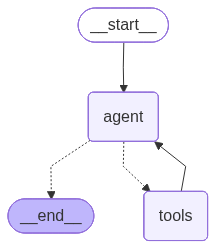

In [13]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))  


In [14]:
# 호출
from langchain_core.messages import HumanMessage

# query = 'What currency is in Billy Giles\'birthplace?'   # 이 질문을 고른 이유 : 논문에 나온 쿼리임 (Adaptive Approch)

query = 'What currency is in Billy Giles\'birthplace? Find the currency and email it to 4yrpbusiness@gmail.com'  # gmail took을 활용하기 위한 쿼리
for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'): # full state를 볼 수 있음
    chunk['messages'][-1].pretty_print()


================================ Human Message =================================

What currency is in Billy Giles'birthplace?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_miHwkotyK4u7l15KInfSVVwH)
 Call ID: call_miHwkotyK4u7l15KInfSVVwH
  Args:
    query: Billy Giles birthplace
================================= Tool Message =================================
Name: duckduckgo_search

Is this your ancestor? Compare DNA and explore genealogy for WilliamGilesborn abt. 1718 Henrico, Colony of Virginia died 1794 Amelia, Virginia, United States including ancestors + descendants + 7 genealogist comments + DNA connections + more in the free family tree community. Genealogy for WilliamGiles(1686 - 1727) family tree on Geni, with over 275 million profiles of ancestors and living relatives. William BranchGiles: A Biography by Dice Robins Anderson Publication date 1915 Collection internetarchivebooks Contributor Internet Archi

In [15]:
# 이걸 워크플로우로 작성했다면, 
# 복잡한 츨로우가 나올 수도 있음.
# 에이전트를 구축하면, 단순 검색 도구만 줘도 생성할 워크플로우들의 기능을 구현할 수  있다.

#### gmail toolkit 도구 활용

In [16]:
%pip install -qU "langchain-google-community[gmail]"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
